In [1]:
!pip install -q ucimlrepo xgboost

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)

X = predict_students_dropout_and_academic_success.data.features
y = predict_students_dropout_and_academic_success.data.targets

In [4]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature shape: (4424, 36)
Target shape: (4424, 1)

Features:
   Marital Status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1     

In [5]:
print(X.columns.tolist())

['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


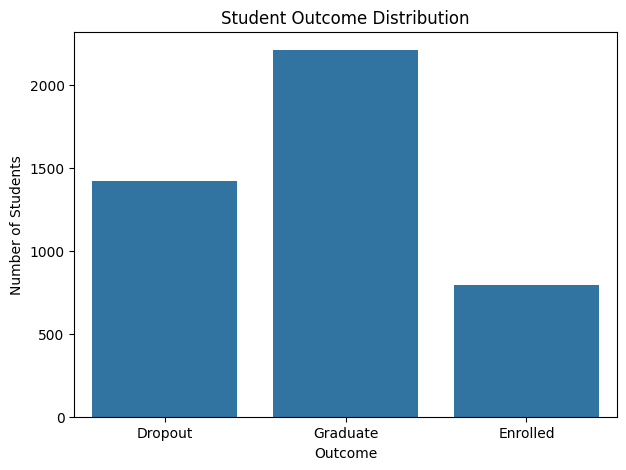

In [6]:
print(y.iloc[:, 0].value_counts())
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y.iloc[:, 0]
)

plt.title("Student Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")
plt.show()

In [7]:
print("Missing values in X:")
print(X.isnull().sum().sum())

print("\nMissing values in y:")
print(y.isnull().sum().sum())

Missing values in X:
0

Missing values in y:
0


In [8]:
y = y.iloc[:, 0]

print(y.unique())

['Dropout' 'Graduate' 'Enrolled']


In [9]:
target_mapping = {
    "Dropout": 0,
    "Enrolled": 1,
    "Graduate": 2
}

y = y.map(target_mapping)

print(y.value_counts())

Target
2    2209
0    1421
1     794
Name: count, dtype: int64


In [10]:
print(X.dtypes)

Marital Status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [11]:
categorical_features = [
    "Marital status",
    "Application mode",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Gender",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "International"
]

numerical_features = [
    "Application order",
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

In [12]:
all_selected_features = categorical_features + numerical_features

missing_features = set(X.columns) - set(all_selected_features)
extra_features = set(all_selected_features) - set(X.columns)

print("Missing features:", missing_features)
print("Extra features:", extra_features)

Missing features: {'Marital Status'}
Extra features: {'Marital status'}


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3539, 36)
Testing data: (885, 36)


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [16]:
# Fix the capitalization mismatch for 'Marital Status'
categorical_features = [f.replace('Marital status', 'Marital Status') for f in categorical_features]
preprocessor.transformers[0] = ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (3539, 244)
Processed testing shape: (885, 244)


In [17]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

logistic_pred = logistic_model.predict(X_test_processed)

In [18]:
print("Logistic Regression")

print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=["Dropout", "Enrolled", "Graduate"]
    )
)

Logistic Regression
              precision    recall  f1-score   support

     Dropout       0.78      0.75      0.77       284
    Enrolled       0.55      0.39      0.46       159
    Graduate       0.81      0.91      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.69      0.69       885
weighted avg       0.75      0.77      0.76       885



In [19]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(X_train_processed, y_train)

random_forest_pred = random_forest_model.predict(X_test_processed)

In [20]:
print("Random Forest")

print(
    classification_report(
        y_test,
        random_forest_pred,
        target_names=["Dropout", "Enrolled", "Graduate"]
    )
)

Random Forest
              precision    recall  f1-score   support

     Dropout       0.80      0.75      0.77       284
    Enrolled       0.56      0.30      0.39       159
    Graduate       0.78      0.93      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.66      0.67       885
weighted avg       0.74      0.76      0.74       885



In [21]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

xgb_pred = xgb_model.predict(X_test_processed)

In [22]:
print("XGBoost")

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["Dropout", "Enrolled", "Graduate"]
    )
)

XGBoost
              precision    recall  f1-score   support

     Dropout       0.80      0.73      0.76       284
    Enrolled       0.50      0.41      0.45       159
    Graduate       0.81      0.91      0.86       442

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



In [23]:
models = {
    "Logistic Regression": logistic_pred,
    "Random Forest": random_forest_pred,
    "XGBoost": xgb_pred
}

results = []

for name, predictions in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted"
        )
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.768362   0.754478  0.768362  0.757333
1        Random Forest  0.762712   0.744750  0.762712  0.743182
2              XGBoost  0.760452   0.749733  0.760452  0.752213


In [24]:
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.768362   0.754478  0.768362  0.757333
2              XGBoost  0.760452   0.749733  0.760452  0.752213
1        Random Forest  0.762712   0.744750  0.762712  0.743182


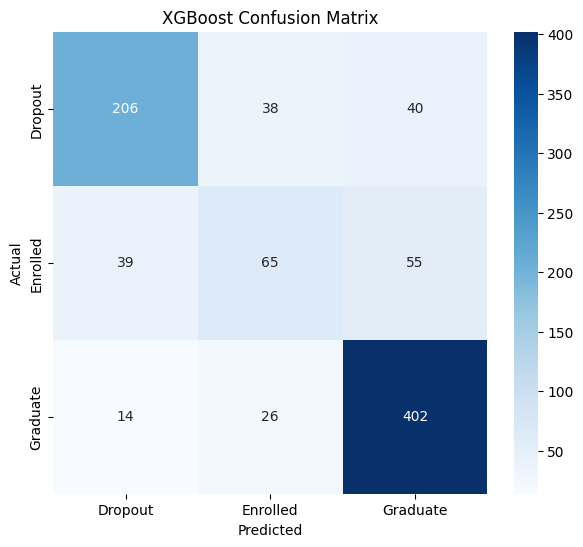

In [25]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Dropout", "Enrolled", "Graduate"],
    yticklabels=["Dropout", "Enrolled", "Graduate"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [26]:
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))

                                               Feature  Importance
238     numerical__Curricular units 2nd sem (approved)    0.064849
219             categorical__Tuition fees up to date_0    0.033833
220             categorical__Tuition fees up to date_1    0.027193
25                             categorical__Course_171    0.027043
232     numerical__Curricular units 1st sem (approved)    0.017092
230     numerical__Curricular units 1st sem (enrolled)    0.016431
236     numerical__Curricular units 2nd sem (enrolled)    0.013927
39                            categorical__Course_9853    0.013669
139                 categorical__Mother's occupation_0    0.013104
128             categorical__Father's qualification_34    0.012179
221                  categorical__Scholarship holder_0    0.012086
222                  categorical__Scholarship holder_1    0.011276
231  numerical__Curricular units 1st sem (evaluations)    0.011255
96              categorical__Mother's qualification_34    0.01

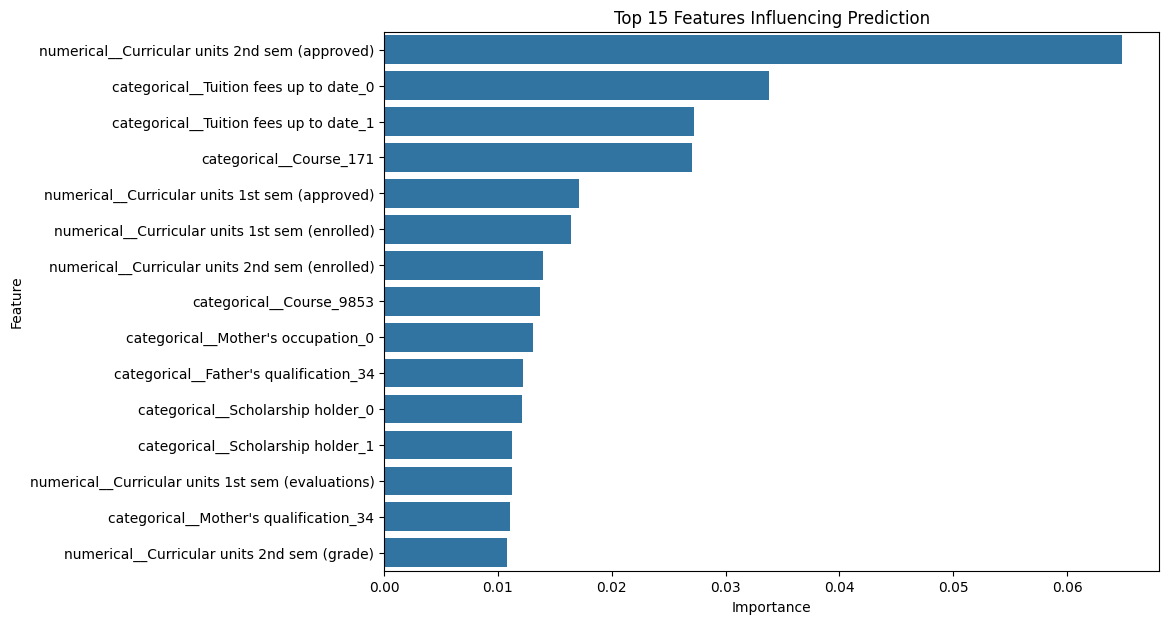

In [27]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()